# Create design matrix
- Map response as a regressor
- Then split it up based on valence and volatility
- See how they are correlated amongst each other

In [1]:
import utils

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import math
import os
from nilearn.glm.first_level import make_first_level_design_matrix, check_design_matrix
from nilearn.plotting import plot_design_matrix, plot_design_matrix_correlation

#from analyses_behavioural.modelling.martin_modelling.plots import subjectively_correct

plt.rcParams.update(plt.rcParamsDefault)
pd.set_option('display.max_columns', None)

In [2]:
# Make output folder
output_dir = os.path.join('..','plots','fMRI','design_matrices')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

In [3]:
# To load the trigger files
def find_trigger_file(pattern: str, folder: str = '.') -> pd.DataFrame:
    folder = Path(folder)
    matches = list(folder.glob(pattern))

    if len(matches) == 0:
        raise FileNotFoundError(f"No files matching '{pattern}' in {folder}")
    if len(matches) > 1:
        raise ValueError(f"Multiple files match '{pattern}': {matches}")

    return pd.read_csv(matches[0], delimiter=';')

In [4]:
# Preparation
plot_range = [0, 6]

# Loads the datapath, subject_id's and session numbers
raw_output_path = '/Volumes/project/3025011.02/raw/'
unique_subject_ids = [52, 53, 54, 55, 57]
unique_sessions = [2, 3, 4]

# Now create a boxcar for every single trial
boxcar_duration = 1.7
# Define the maximum displacement for volumes that are excluded [mm]
framewise_displacement_limit = 0.5
# Filter out objectively incorrect trials
filter_out_incorrect_trials = True

# Load and combine the datasets
combined_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, fmri_analysis=True)

print(combined_dataframe)

     subject_id     session  previous_outcome subjectively_correct  stay
0       sub-052  session-02              <NA>                 Late  <NA>
1       sub-052  session-02              <NA>                False  <NA>
2       sub-052  session-02              <NA>                 True  <NA>
3       sub-052  session-02              <NA>                 True  <NA>
4       sub-052  session-02              <NA>                False     1
...         ...         ...               ...                  ...   ...
6775    sub-057  session-04              <NA>                 True  <NA>
6776    sub-057  session-04                 1                 True     1
6777    sub-057  session-04                 1                 True     1
6778    sub-057  session-04                 1                 True     1
6779    sub-057  session-04                 1                False  <NA>

[6780 rows x 5 columns]
      trial  emotional_cue_time  response objectively_correct  \
0         0        1.769530e+09   

/Volumes/kenvdzee/Documents/phd_1_analysis/utils/import_functions.py:757: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  removed_trials['removed_trial'] = 'removed_trial'


Creating event file for subject 52 and session 2
                                  trial_type        onset  duration
2                              removed_trial     5.147119  1.369851
5                              removed_trial     9.591200  0.844241
8                              removed_trial    14.259931  0.784553
11                             removed_trial    18.562464  0.690180
14                             removed_trial    23.018315  0.717532
17                             removed_trial    26.956866  0.603045
20                             removed_trial    31.539459  0.720134
23                             removed_trial    34.923889  0.626518
24       happy-most_rewarding_avoid-volatile    38.511245  0.647203
25          happy-executed_approach-volatile    38.511245  0.647203
27       happy-most_rewarding_avoid-volatile    42.248241  0.721384
28          happy-executed_approach-volatile    42.248241  0.721384
30    angry-most_rewarding_approach-volatile    45.599828  0.595641

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


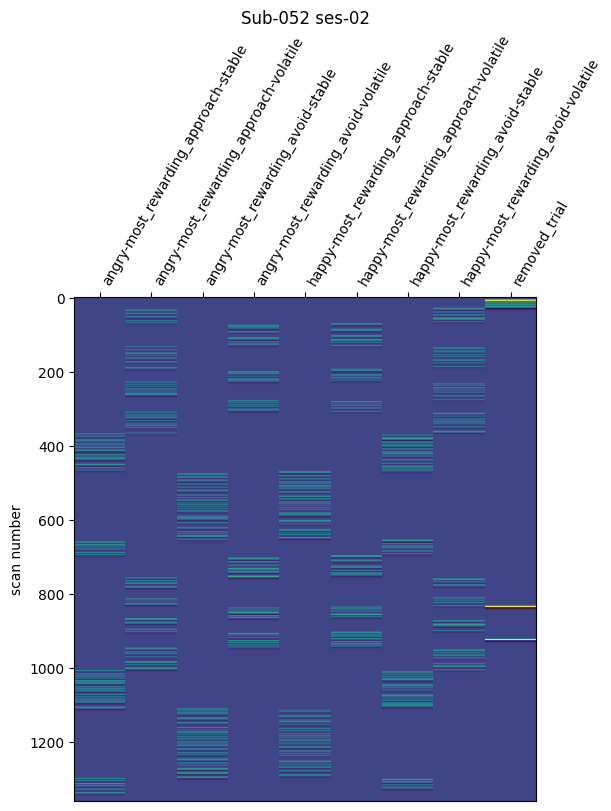

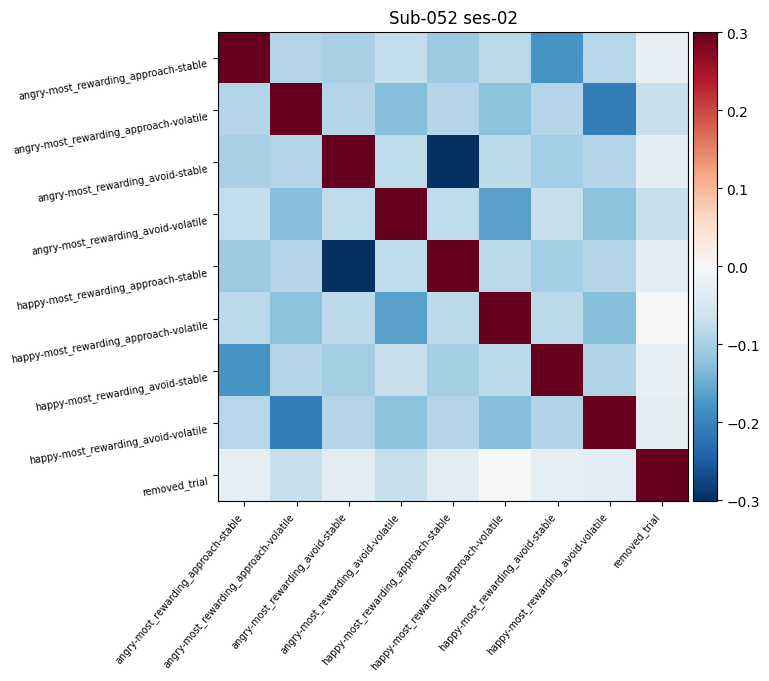

confound title: b_framewise_displacement
list of confounds: ['framewise_displacement']

3.085966201322557% of volumes have been removed.

confound title: c_trans_rot
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

3.085966201322557% of volumes have been removed.

confound title: d_derivative1
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1']

3.085966201322557% of volumes have been removed.

confound title: e_power2
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'trans_x_power2', 'trans_y_power2', 'trans_z_power2', 'rot_x_power2', 'rot_y_power2', 'rot_z_po

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


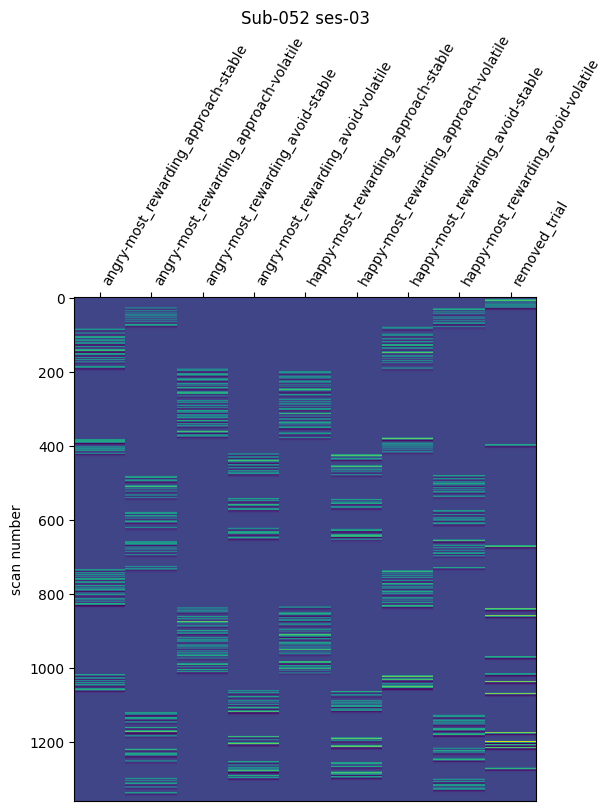

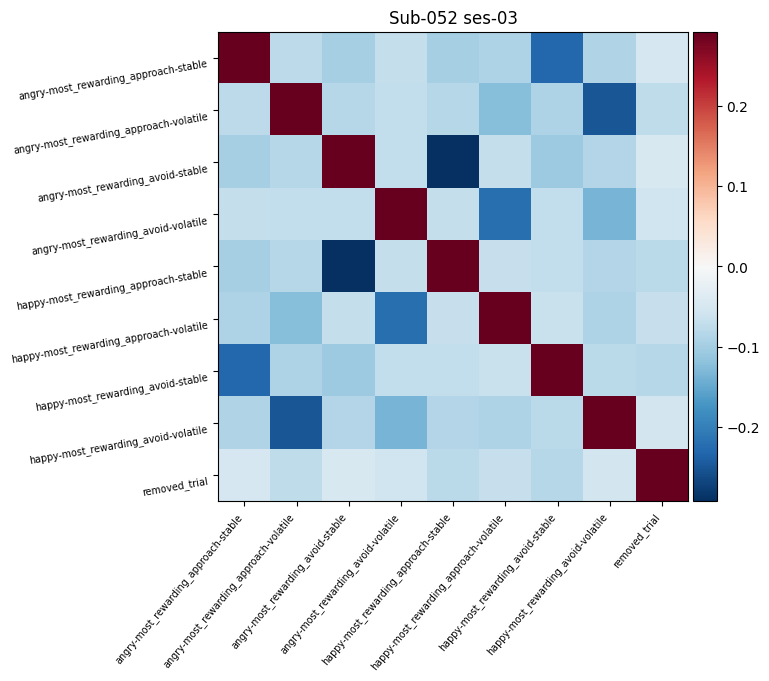

confound title: b_framewise_displacement
list of confounds: ['framewise_displacement']

5.9515062454077885% of volumes have been removed.

confound title: c_trans_rot
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

5.9515062454077885% of volumes have been removed.

confound title: d_derivative1
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1']

5.9515062454077885% of volumes have been removed.

confound title: e_power2
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'trans_x_power2', 'trans_y_power2', 'trans_z_power2', 'rot_x_power2', 'rot_y_power2', 'rot_z

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


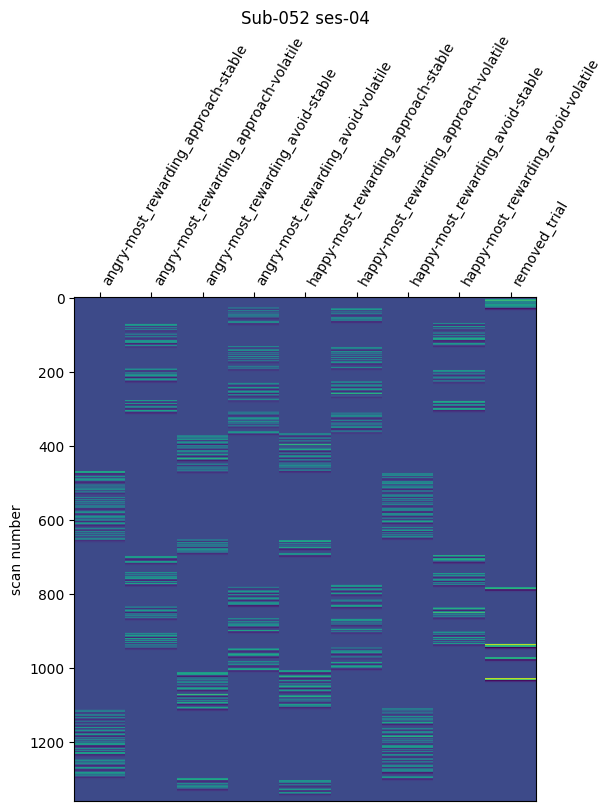

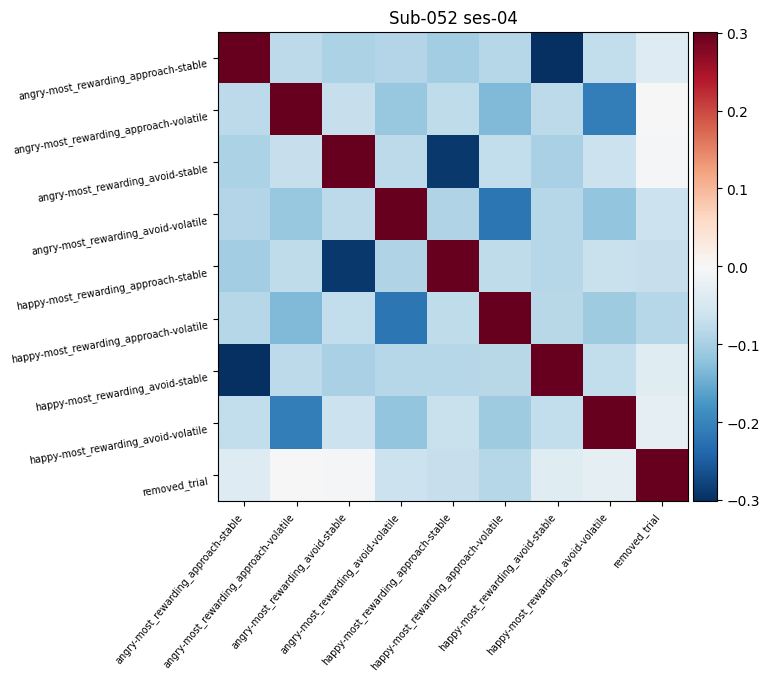

confound title: b_framewise_displacement
list of confounds: ['framewise_displacement']

1.4695077149155034% of volumes have been removed.

confound title: c_trans_rot
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

1.4695077149155034% of volumes have been removed.

confound title: d_derivative1
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1']

1.4695077149155034% of volumes have been removed.

confound title: e_power2
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'trans_x_power2', 'trans_y_power2', 'trans_z_power2', 'rot_x_power2', 'rot_y_power2', 'rot_z

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


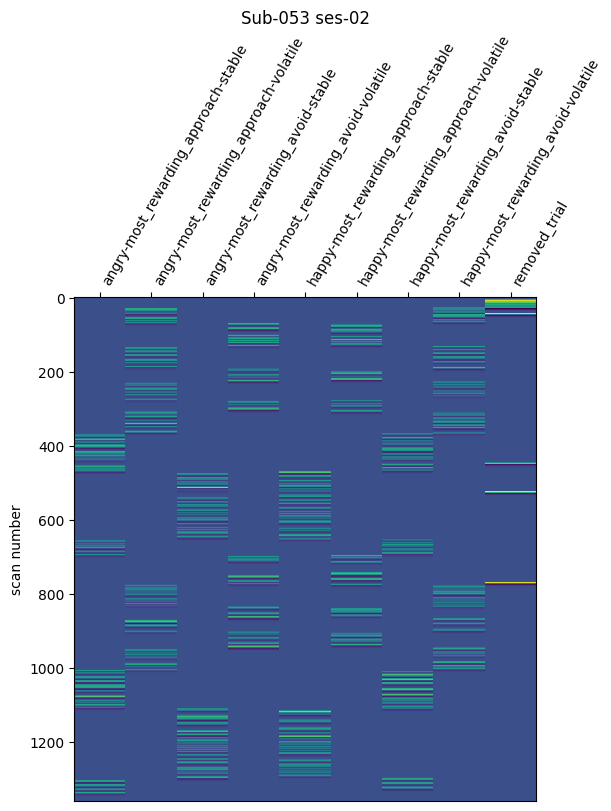

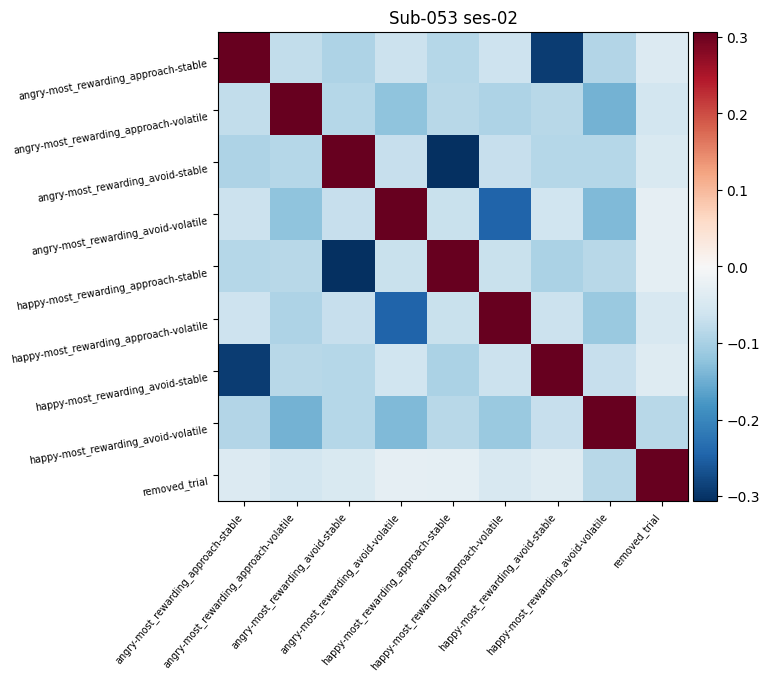

confound title: b_framewise_displacement
list of confounds: ['framewise_displacement']

3.4533431300514326% of volumes have been removed.

confound title: c_trans_rot
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

3.4533431300514326% of volumes have been removed.

confound title: d_derivative1
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1']

3.4533431300514326% of volumes have been removed.

confound title: e_power2
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'trans_x_power2', 'trans_y_power2', 'trans_z_power2', 'rot_x_power2', 'rot_y_power2', 'rot_z

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


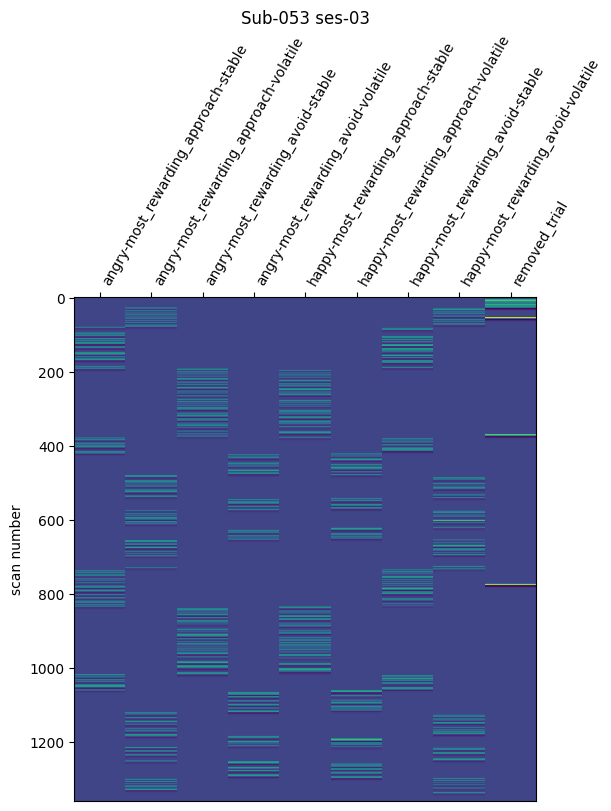

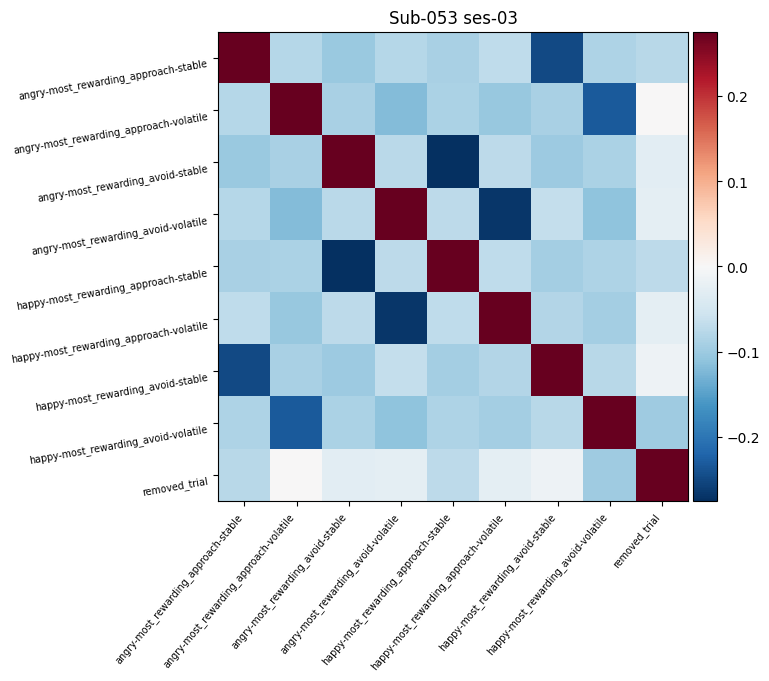

confound title: b_framewise_displacement
list of confounds: ['framewise_displacement']

5.9515062454077885% of volumes have been removed.

confound title: c_trans_rot
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

5.9515062454077885% of volumes have been removed.

confound title: d_derivative1
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1']

5.9515062454077885% of volumes have been removed.

confound title: e_power2
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'trans_x_power2', 'trans_y_power2', 'trans_z_power2', 'rot_x_power2', 'rot_y_power2', 'rot_z

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


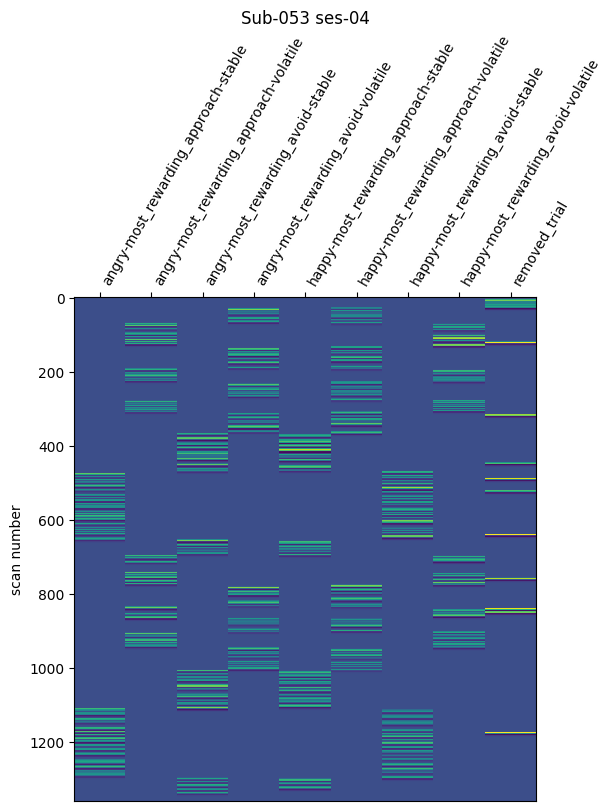

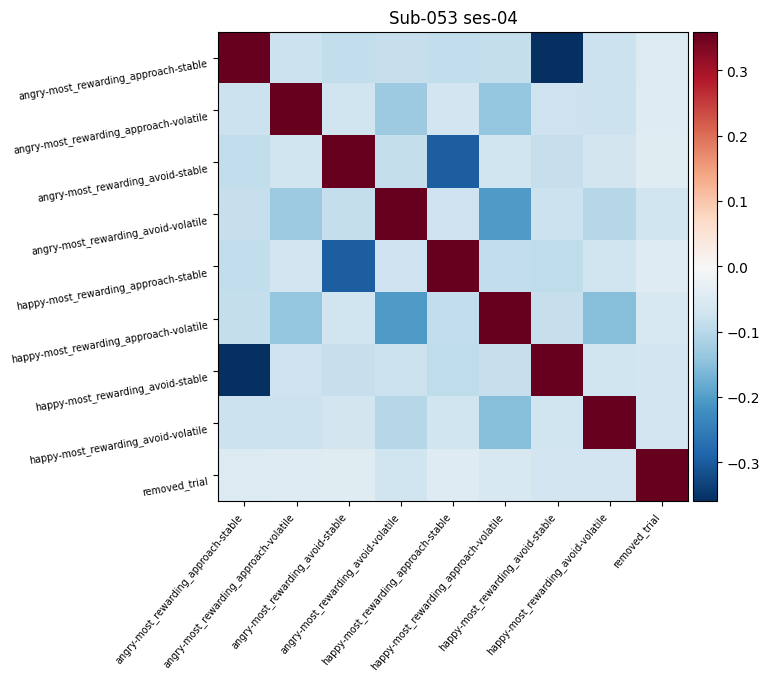

confound title: b_framewise_displacement
list of confounds: ['framewise_displacement']

2.718589272593681% of volumes have been removed.

confound title: c_trans_rot
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

2.718589272593681% of volumes have been removed.

confound title: d_derivative1
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1']

2.718589272593681% of volumes have been removed.

confound title: e_power2
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'trans_x_power2', 'trans_y_power2', 'trans_z_power2', 'rot_x_power2', 'rot_y_power2', 'rot_z_po

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


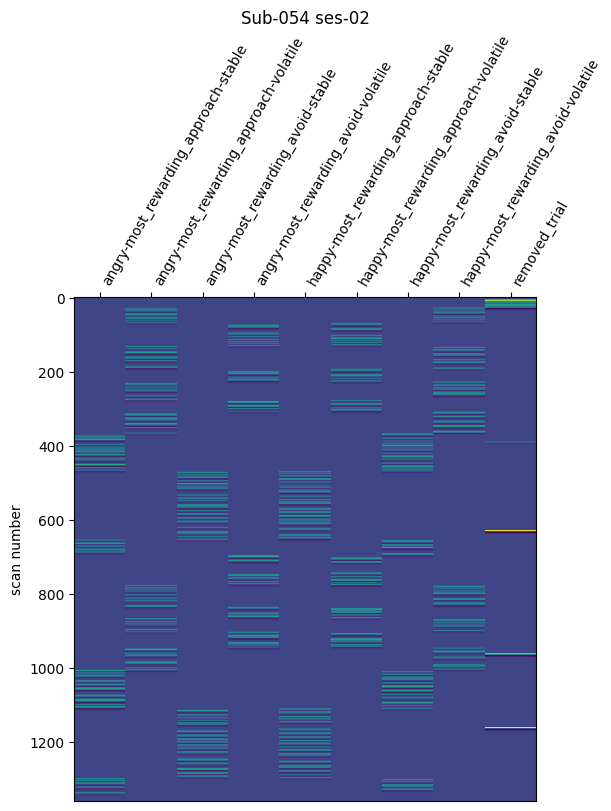

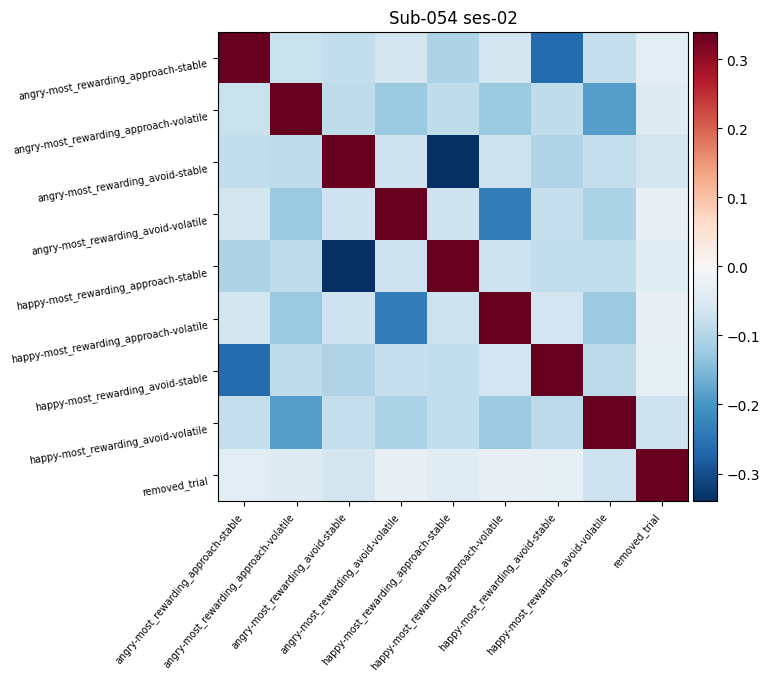

confound title: b_framewise_displacement
list of confounds: ['framewise_displacement']

2.351212343864805% of volumes have been removed.

confound title: c_trans_rot
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

2.351212343864805% of volumes have been removed.

confound title: d_derivative1
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1']

2.351212343864805% of volumes have been removed.

confound title: e_power2
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'trans_x_power2', 'trans_y_power2', 'trans_z_power2', 'rot_x_power2', 'rot_y_power2', 'rot_z_po

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


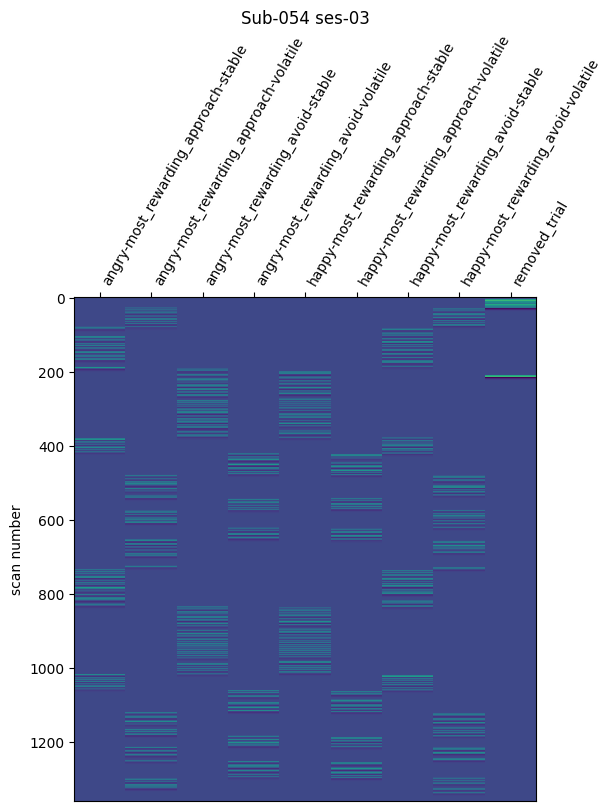

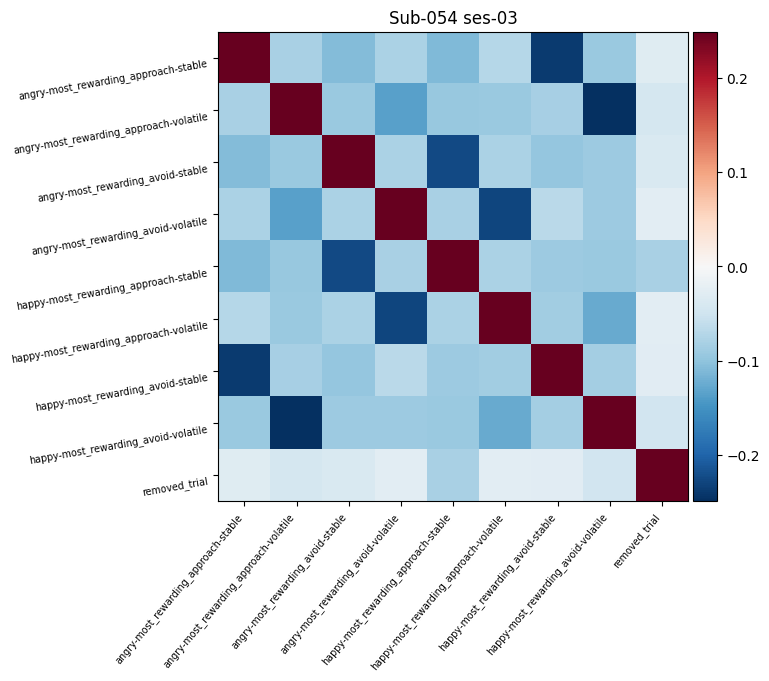

confound title: b_framewise_displacement
list of confounds: ['framewise_displacement']

0.440852314474651% of volumes have been removed.

confound title: c_trans_rot
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

0.440852314474651% of volumes have been removed.

confound title: d_derivative1
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1']

0.440852314474651% of volumes have been removed.

confound title: e_power2
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'trans_x_power2', 'trans_y_power2', 'trans_z_power2', 'rot_x_power2', 'rot_y_power2', 'rot_z_po

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


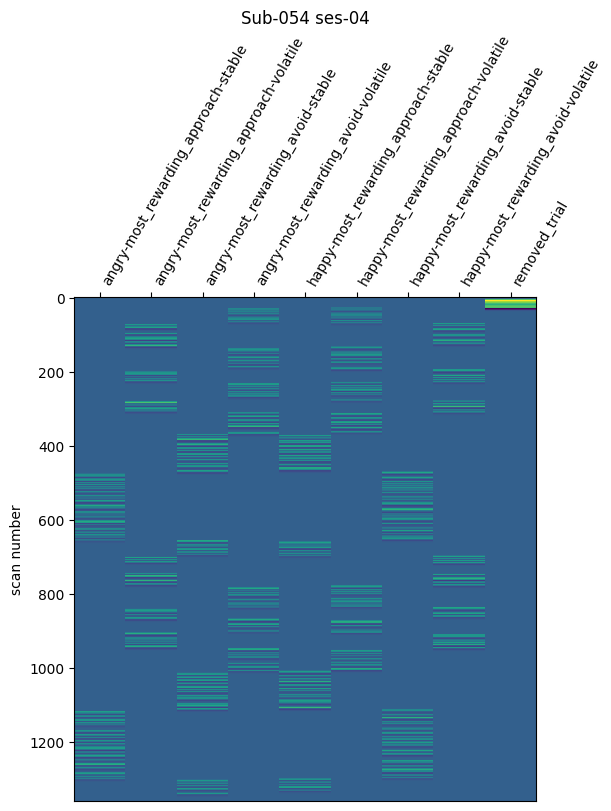

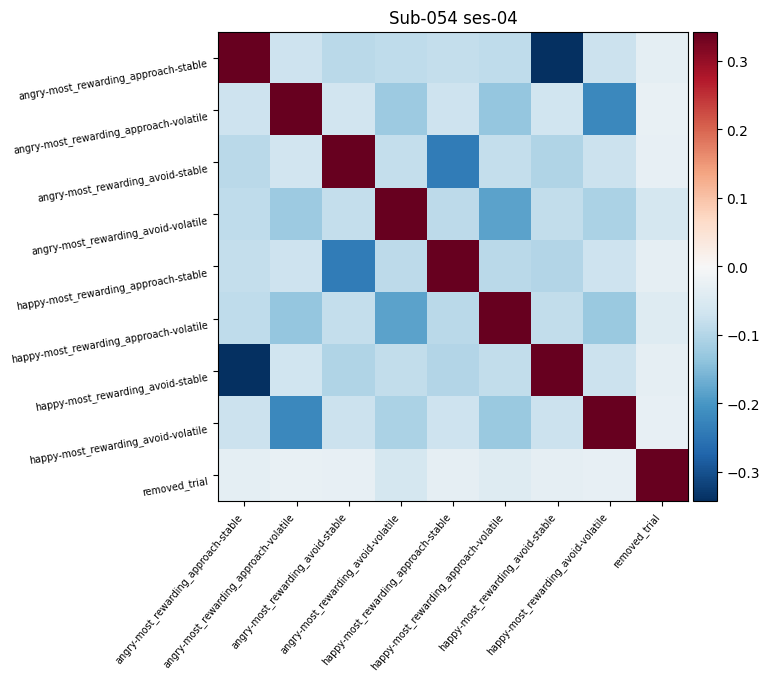

confound title: b_framewise_displacement
list of confounds: ['framewise_displacement']

3.6002939015429827% of volumes have been removed.

confound title: c_trans_rot
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

3.6002939015429827% of volumes have been removed.

confound title: d_derivative1
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1']

3.6002939015429827% of volumes have been removed.

confound title: e_power2
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'trans_x_power2', 'trans_y_power2', 'trans_z_power2', 'rot_x_power2', 'rot_y_power2', 'rot_z

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


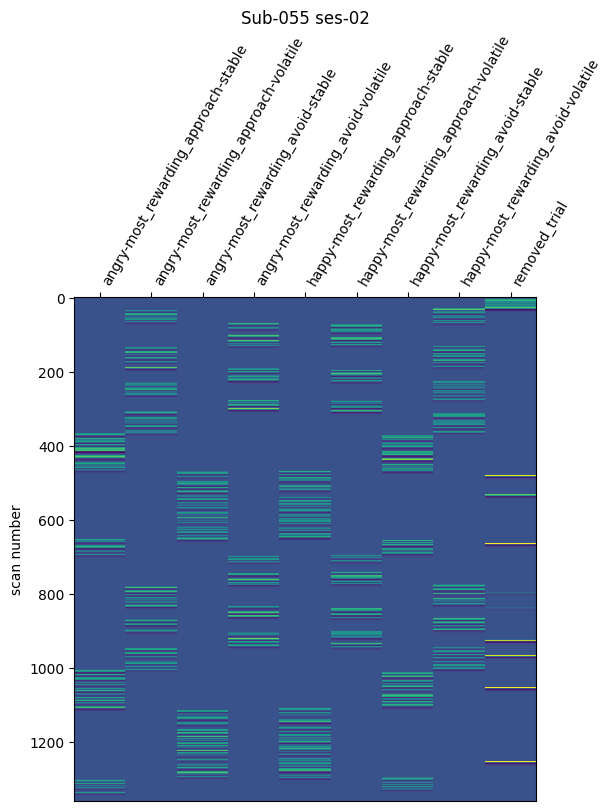

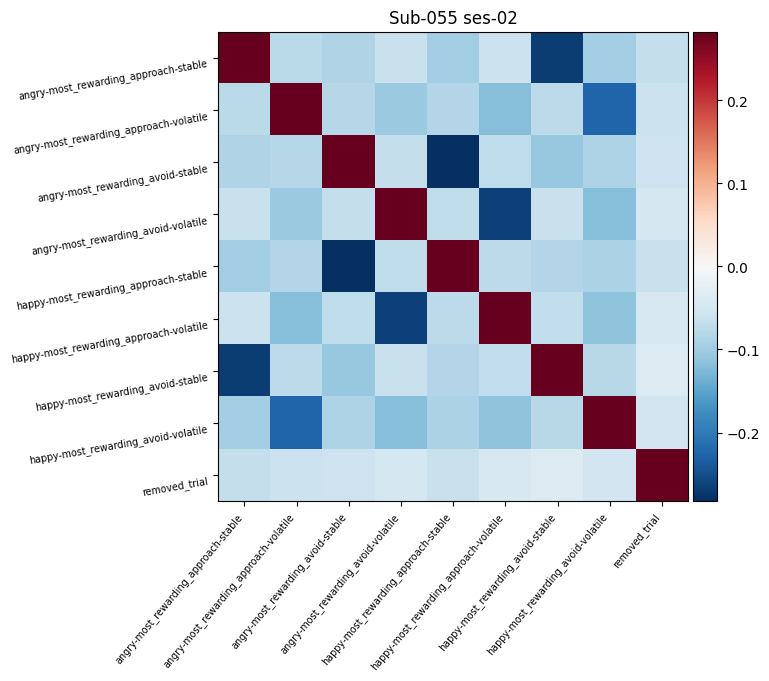

confound title: b_framewise_displacement
list of confounds: ['framewise_displacement']

0.1469507714915503% of volumes have been removed.

confound title: c_trans_rot
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

0.1469507714915503% of volumes have been removed.

confound title: d_derivative1
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1']

0.1469507714915503% of volumes have been removed.

confound title: e_power2
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'trans_x_power2', 'trans_y_power2', 'trans_z_power2', 'rot_x_power2', 'rot_y_power2', 'rot_z

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


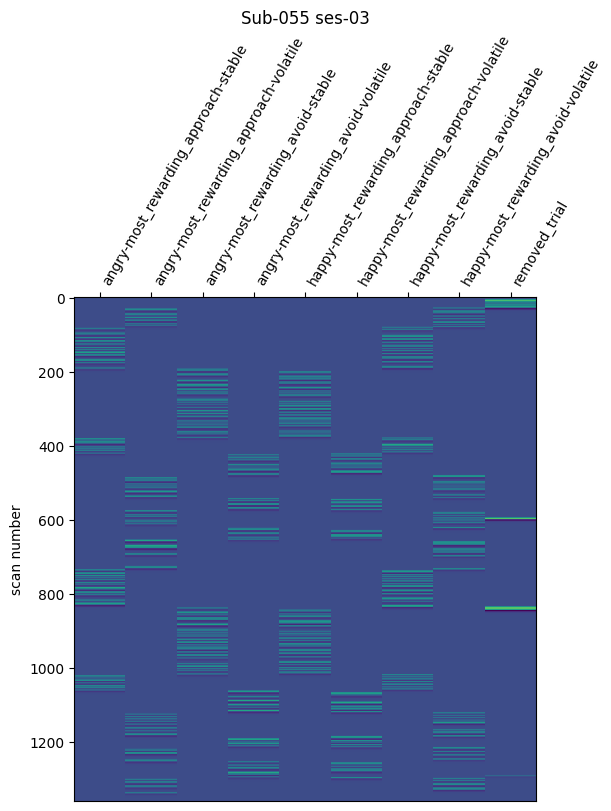

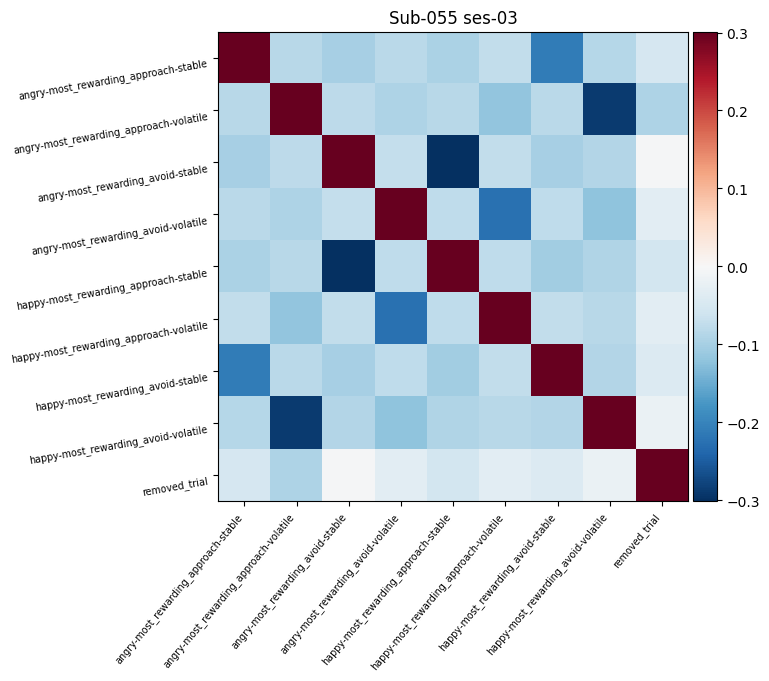

confound title: b_framewise_displacement
list of confounds: ['framewise_displacement']

0.2939015429831006% of volumes have been removed.

confound title: c_trans_rot
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

0.2939015429831006% of volumes have been removed.

confound title: d_derivative1
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1']

0.2939015429831006% of volumes have been removed.

confound title: e_power2
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'trans_x_power2', 'trans_y_power2', 'trans_z_power2', 'rot_x_power2', 'rot_y_power2', 'rot_z

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


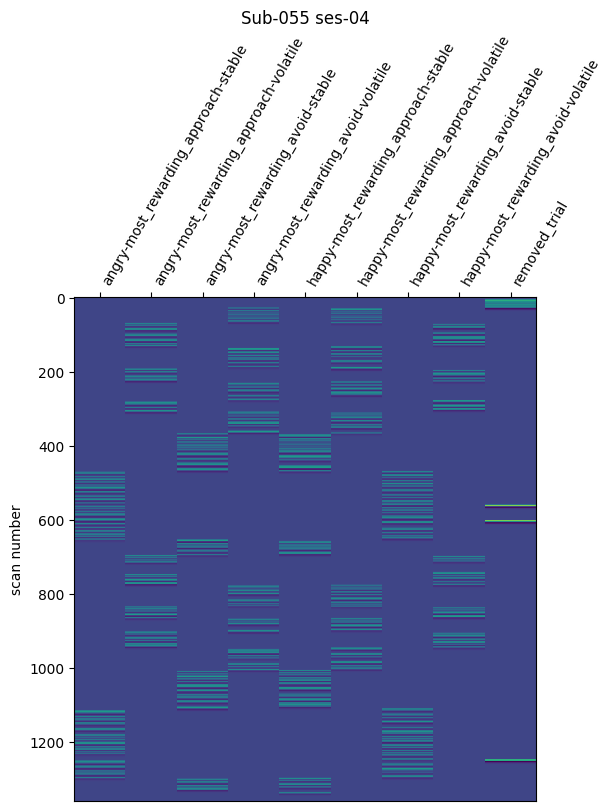

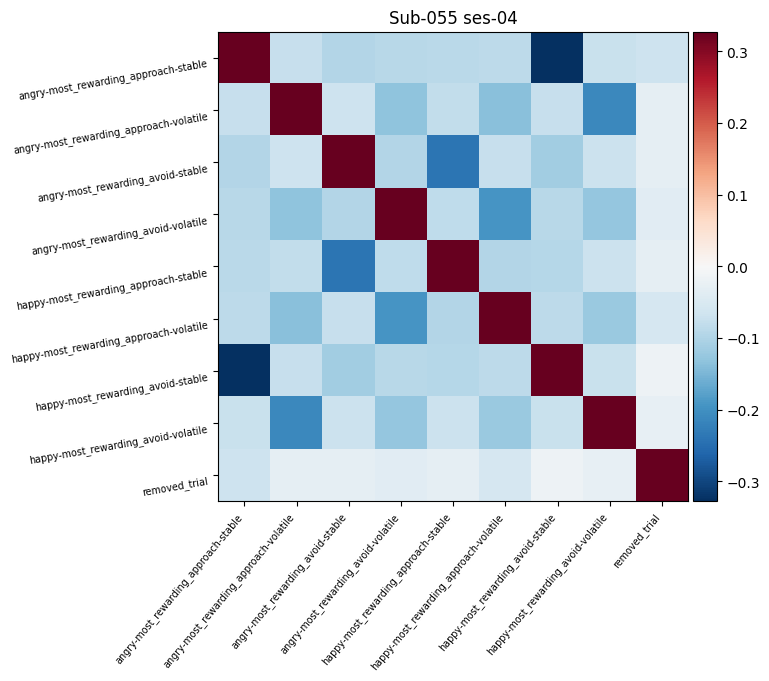

confound title: b_framewise_displacement
list of confounds: ['framewise_displacement']

0.2939015429831006% of volumes have been removed.

confound title: c_trans_rot
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

0.2939015429831006% of volumes have been removed.

confound title: d_derivative1
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1']

0.2939015429831006% of volumes have been removed.

confound title: e_power2
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'trans_x_power2', 'trans_y_power2', 'trans_z_power2', 'rot_x_power2', 'rot_y_power2', 'rot_z

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


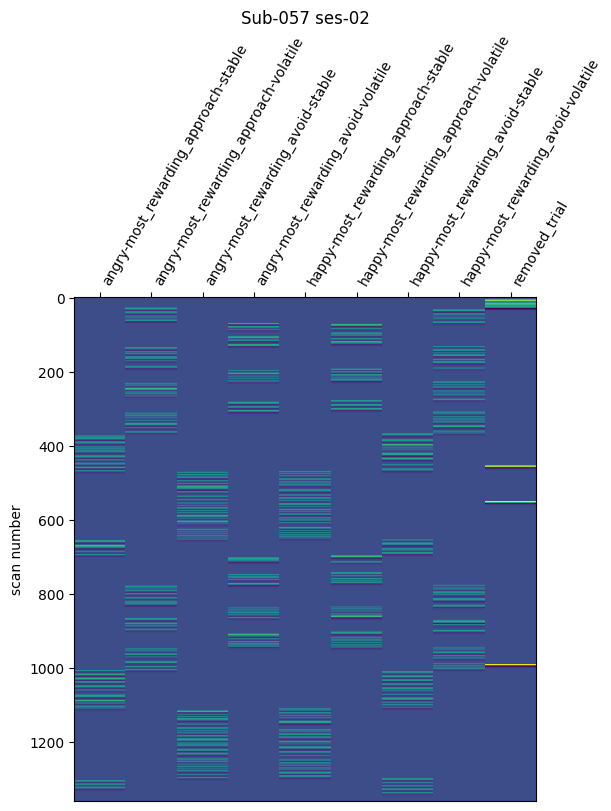

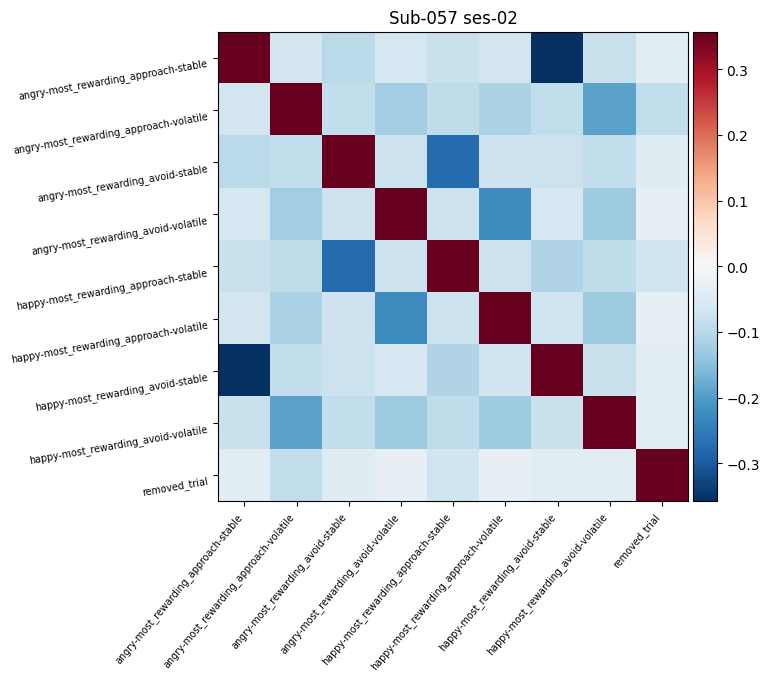

confound title: b_framewise_displacement
list of confounds: ['framewise_displacement']

0.0% of volumes have been removed.

confound title: c_trans_rot
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

0.0% of volumes have been removed.

confound title: d_derivative1
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1']

0.0% of volumes have been removed.

confound title: e_power2
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'trans_x_power2', 'trans_y_power2', 'trans_z_power2', 'rot_x_power2', 'rot_y_power2', 'rot_z_power2']

0.0% of volumes have been removed.

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


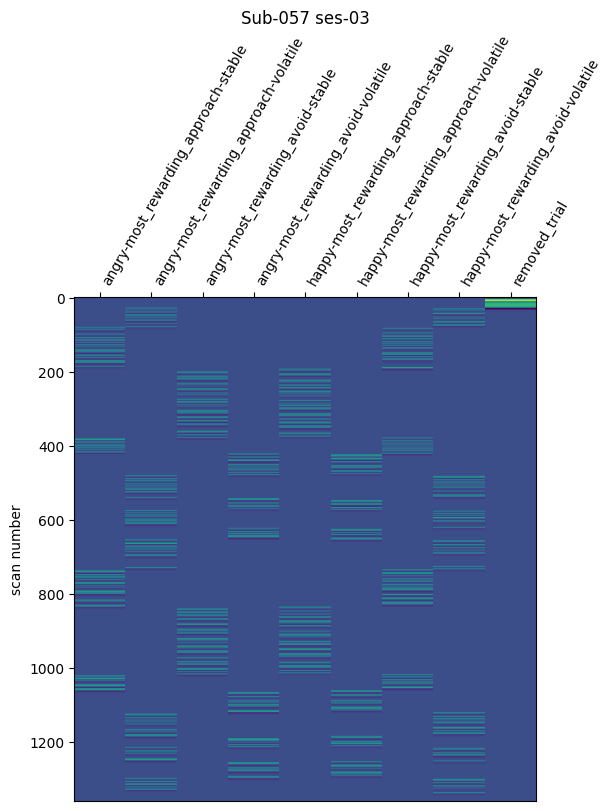

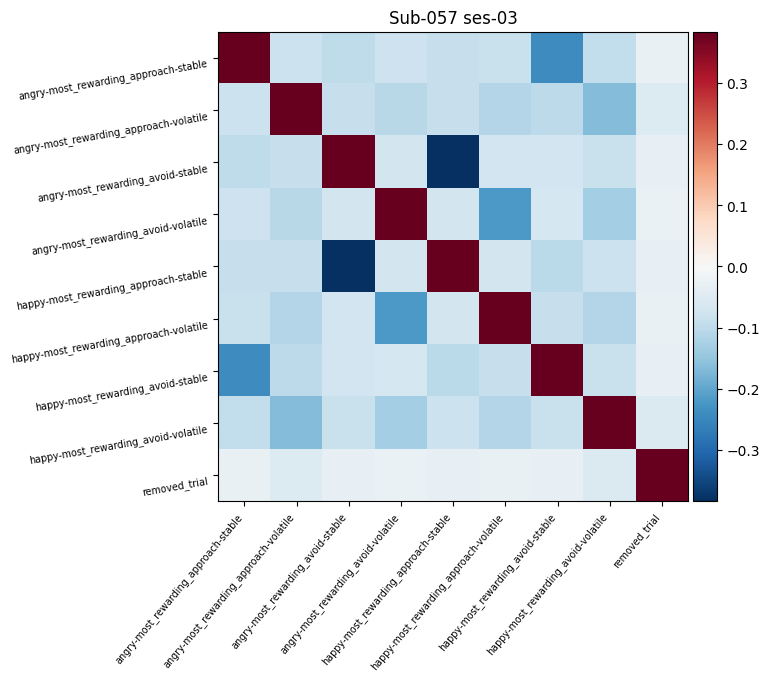

confound title: b_framewise_displacement
list of confounds: ['framewise_displacement']

0.36737692872887584% of volumes have been removed.

confound title: c_trans_rot
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

0.36737692872887584% of volumes have been removed.

confound title: d_derivative1
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1']

0.36737692872887584% of volumes have been removed.

confound title: e_power2
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'trans_x_power2', 'trans_y_power2', 'trans_z_power2', 'rot_x_power2', 'rot_y_power2', 'ro

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Duplicated events were detected. Amplitudes of these events will be summed. You might want to verify your inputs.
  design_matrix = make_first_level_design_matrix(
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_5382/3952267422.py:96: UserWarning: Matrix is singular at working precision, regularizing...
  design_matrix = make_first_level_design_matrix(


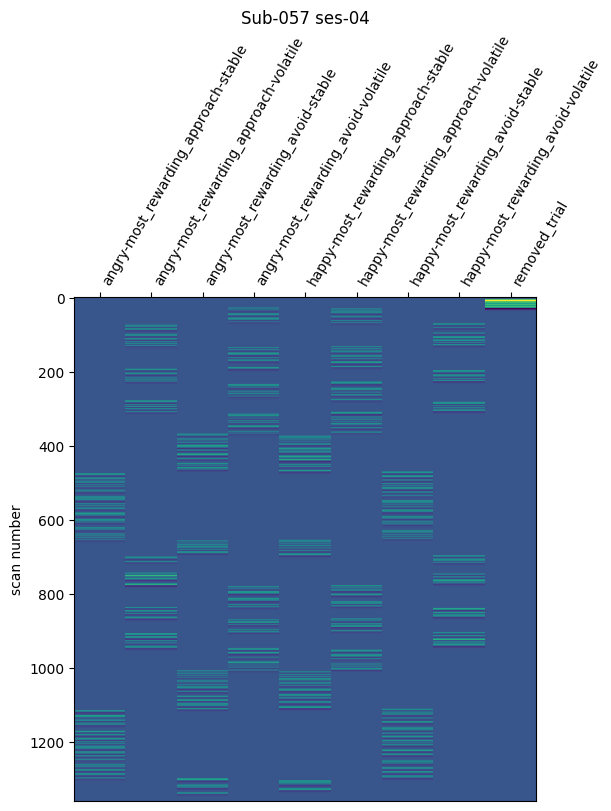

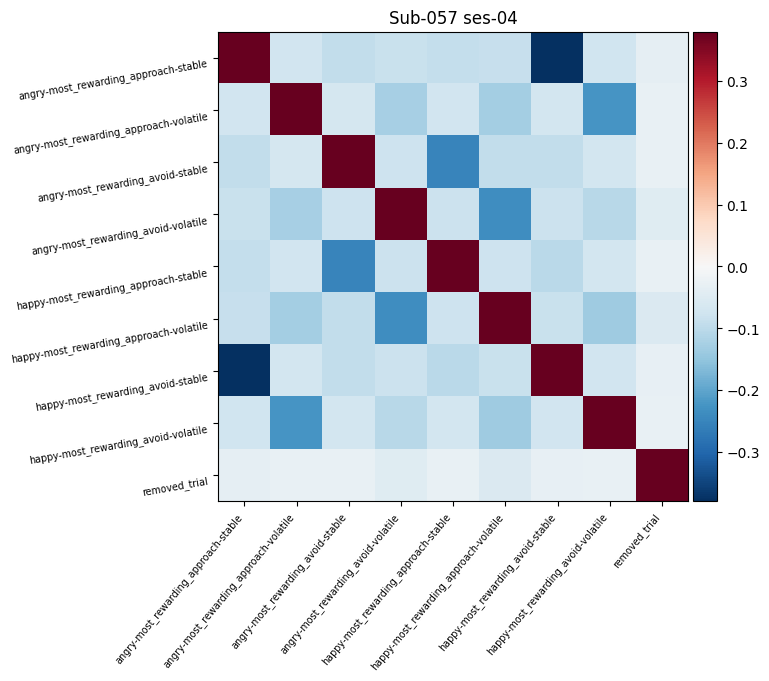

confound title: b_framewise_displacement
list of confounds: ['framewise_displacement']

0.0% of volumes have been removed.

confound title: c_trans_rot
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z']

0.0% of volumes have been removed.

confound title: d_derivative1
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1']

0.0% of volumes have been removed.

confound title: e_power2
list of confounds: ['framewise_displacement', 'trans_x', 'trans_y', 'trans_z', 'rot_x', 'rot_y', 'rot_z', 'trans_x_derivative1', 'trans_y_derivative1', 'trans_z_derivative1', 'rot_x_derivative1', 'rot_y_derivative1', 'rot_z_derivative1', 'trans_x_power2', 'trans_y_power2', 'trans_z_power2', 'rot_x_power2', 'rot_y_power2', 'rot_z_power2']

0.0% of volumes have been removed.

In [17]:
pd.set_option('display.max_rows', None)

for subject_id in unique_subject_ids:
    for session in unique_sessions:
        # Set subject raw folder for later use:
        project_folder = '/Volumes/project/3025011.02'
        subject_raw_folder = f'{project_folder}/raw/sub-{subject_id:03}/ses-mri{session:02}'
        subject_func_folder = f'{project_folder}/bids/sub-{subject_id:03}/ses-mri{session:02}/func'
        fsl_folder = f'{project_folder}/bids/derivatives/fsl/sub-{subject_id:03}/ses-mri{session:02}/func'
        confounds_file = f'{project_folder}/bids/derivatives/fmriprep/sub-{subject_id:03}/ses-mri{session:02}/func/sub-{subject_id:03}_ses-mri{session:02}_task-AARL_desc-confounds_timeseries.tsv'
        os.makedirs(fsl_folder, exist_ok=True)

        # If participant does not have subject data yet
        if not os.path.exists(confounds_file):
            print(f'fMRIprep has not yet been run for subject {subject_id} and session {session}')
            continue
        else:
            print(f'Creating event file for subject {subject_id} and session {session}')

        # Add subject and session columns
        dataframe = combined_dataframe[combined_dataframe['subject_id'] == f'sub-{subject_id:03}']
        dataframe = dataframe[dataframe['session'] == f'session-{session:02}']

        # Create version of comments that only contain responses, cues and feedback
        dataframe['contains_response'] = np.where(dataframe['response'].notna(), 'response', '')
        dataframe['contains_cue'] = np.where(dataframe['valence'].notna(), 'cue', '')
        feedback_binary = [
            dataframe['subjectively_correct'].isin([True, 'True']),
            dataframe['subjectively_correct'].isin([False, 'False']),
        ]
        feedback_strings = ['subjectively_correct', 'subjectively_incorrect']
        dataframe['contains_feedback'] = np.select(feedback_binary, feedback_strings, default='')

        # Combine variables
        dataframe['most_rewarding_response'] = dataframe['most_rewarding_response'].replace({'approach': 'most_rewarding_approach', 'avoid': 'most_rewarding_avoid'})
        dataframe['executed_response'] = dataframe['response'].replace({'approach': 'executed_approach', 'avoid': 'executed_avoid'})
        dataframe['cue-valence-instructed_response-volatility'] = dataframe['valence'] + '-' + dataframe['most_rewarding_response'] + '-' + dataframe['volatility']
        dataframe['cue-valence-executed_response-volatility'] = dataframe['valence'] + '-' + dataframe['executed_response'] + '-' + dataframe['volatility']

        # Determine when the scan for the first volume starts
        trigger_signals = find_trigger_file(f'trigger_signals_sub-{subject_id:03}_session-{session:02}*.csv', f'{subject_raw_folder}/beh')
        first_volume_start = trigger_signals.loc[trigger_signals['trigger'] == 1, 'trigger_time'].item()
        # Note down when each trial and each response starts
        dataframe['emotional_cue_time'] = dataframe['emotional_cue_time'] - first_volume_start
        dataframe['response_time'] = dataframe['response_time'] - first_volume_start
        dataframe['feedback_time'] = dataframe['feedback_time'] - first_volume_start

        # Create a boxcar
        dataframe['onset'] = dataframe['emotional_cue_time']
        #dataframe['duration'] = boxcar_duration
        dataframe['duration'] = dataframe['feedback_time'] - dataframe['onset'] + 0.1 # time that the visual feedback is shown

        # Restructure into a time-series
        restructured_rows = []
        for _, row in dataframe.iterrows():
            restructured_rows.append({'trial_type': row['cue-valence-instructed_response-volatility'], 'onset': row['onset'], 'duration': row['duration']})
            restructured_rows.append({'trial_type': row['cue-valence-executed_response-volatility'], 'onset': row['onset'], 'duration': row['duration']})
            restructured_rows.append({'trial_type': row['removed_trial'], 'onset': row['onset'], 'duration': row['duration']})

        # Convert to dataframe
        data_design_matrix = pd.DataFrame(restructured_rows)

        # Now create the design matrix and save it
        events = pd.DataFrame(
            {"trial_type": data_design_matrix['trial_type'], "onset": data_design_matrix['onset'], "duration": data_design_matrix['duration']}
        )

        # Make sure that only the removed trials get their own regressor
        events = events[events['trial_type'] != 'non-removed_trial']
        events = events[events['trial_type'].notna()]
        print(events)
        # BIDS compliant event file that FSL doesn't use
        #events.to_csv(os.path.join(f'{subject_func_folder}/sub-{subject_id:03}_ses-mri{session:02}_task-AARL_events.tsv'), sep='\t')

        # Scans timing
        # This method takes the actual triggers instead of assuming that the TR = 1.5 and that no scans are missed
        n_triggers = len(trigger_signals)
        trigger_timepoints = trigger_signals['trigger_time'] - first_volume_start
        trigger_timepoints = trigger_timepoints.tolist()

        # Repetition time
        tr = 1.5
        # Look up number of volumes (since it's multi-echo, we need to divide by 3)
        raw_bold_folder = Path(f'{subject_raw_folder}/006-TaskAARL')
        # Count .IMA files to check if it matches the number of triggers
        ima_files = list(raw_bold_folder.glob('*.IMA'))
        n_volumes = int(len(ima_files) / 3)
        volume_timepoints = np.arange(0, n_volumes) * tr

        if n_triggers != n_volumes:
            raise ValueError(
                f'Number of triggers ({n_triggers}) does not match the number of IMA files ({n_volumes})'
            )

        # fit the hemodynamic response function to the event file
        design_matrix = make_first_level_design_matrix(
            np.array(trigger_timepoints),
            data_design_matrix
        )

        # Explicitly reorder columns
        design_matrix = design_matrix[['angry-most_rewarding_approach-stable', 'angry-most_rewarding_approach-volatile', 'angry-most_rewarding_avoid-stable', 'angry-most_rewarding_avoid-volatile', 'happy-most_rewarding_approach-stable', 'happy-most_rewarding_approach-volatile', 'happy-most_rewarding_avoid-stable', 'happy-most_rewarding_avoid-volatile', 'removed_trial']]

        # Plot said matrix and save it
        fig, ax = plt.subplots(figsize=(6, 8), constrained_layout=True)
        plot_design_matrix(design_matrix, axes=ax)
        ax.set_title(f'Sub-{subject_id:03} ses-{session:02}')
        plt.savefig(os.path.join(output_dir, f'design_matrix_sub-{subject_id:03}_ses-mri{session:02}.pdf'))

        # Now also plot the correlation matrix and save it
        fig, ax = plt.subplots(figsize=(8, 8), constrained_layout=True)
        plot_design_matrix_correlation(design_matrix, axes=ax)
        ax.set_title(f'Sub-{subject_id:03} ses-{session:02}')
        plt.savefig(os.path.join(output_dir, f'regression_correlation_matrix_sub-{subject_id:03}_ses-mri{session:02}.pdf'))
        plt.show()
        # And save a CSV version of it
        correlation_matrix = design_matrix.corr()
        correlation_matrix.round(3).to_csv(os.path.join(output_dir, f'regression_correlation_matrix_sub-{subject_id:03}_ses-mri{session:02}.csv'), sep=';')

        # Because FSL can only accept an event file with one variable in there, we will now split them up
        for trials_type in events['trial_type'].unique():
            trial_specific_events = events[events['trial_type'] == trials_type]
            trial_specific_events = trial_specific_events[['onset', 'duration']].copy()
            trial_specific_events['weight'] = 1.0
            trial_specific_events.to_csv(f'{fsl_folder}/sub-{subject_id:03}_ses-mri{session:02}_task-AARL_regressor_{trials_type}.txt', sep='\t', index=False, header=False)

        # Now select the confounds you want to copy into the FEAT analysis
        confounds_raw = pd.read_csv(confounds_file, sep='\t') # Location of fMRIprep results

        # Different confound combinations
        confound_names = ['a_blanc', 'b_framewise_displacement', 'c_trans_rot', 'd_derivative1', 'e_power2', 'f_a_comp_cor', 'g_dvars', 'h_std_dvars', 'i_rmsd']
        confound_list = [[],
                         ['framewise_displacement'],
                 ['framewise_displacement', 'trans_x','trans_y','trans_z','rot_x','rot_y','rot_z'],
                 ['framewise_displacement', 'trans_x','trans_y','trans_z','rot_x','rot_y','rot_z', 'trans_x_derivative1','trans_y_derivative1','trans_z_derivative1','rot_x_derivative1','rot_y_derivative1','rot_z_derivative1'],
                 ['framewise_displacement', 'trans_x','trans_y','trans_z','rot_x','rot_y','rot_z', 'trans_x_derivative1','trans_y_derivative1','trans_z_derivative1','rot_x_derivative1','rot_y_derivative1','rot_z_derivative1', 'trans_x_power2','trans_y_power2','trans_z_power2','rot_x_power2','rot_y_power2','rot_z_power2'],
                 ['framewise_displacement', 'trans_x','trans_y','trans_z','rot_x','rot_y','rot_z', 'trans_x_derivative1','trans_y_derivative1','trans_z_derivative1','rot_x_derivative1','rot_y_derivative1','rot_z_derivative1', 'trans_x_power2','trans_y_power2','trans_z_power2','rot_x_power2','rot_y_power2','rot_z_power2', 'a_comp_cor_00','a_comp_cor_01','a_comp_cor_02','a_comp_cor_03','a_comp_cor_04','a_comp_cor_05'],
                 ['framewise_displacement', 'trans_x','trans_y','trans_z','rot_x','rot_y','rot_z', 'trans_x_derivative1','trans_y_derivative1','trans_z_derivative1','rot_x_derivative1','rot_y_derivative1','rot_z_derivative1', 'trans_x_power2','trans_y_power2','trans_z_power2','rot_x_power2','rot_y_power2','rot_z_power2', 'a_comp_cor_00','a_comp_cor_01','a_comp_cor_02','a_comp_cor_03','a_comp_cor_04','a_comp_cor_05', 'dvars'],
                 ['framewise_displacement', 'trans_x','trans_y','trans_z','rot_x','rot_y','rot_z', 'trans_x_derivative1','trans_y_derivative1','trans_z_derivative1','rot_x_derivative1','rot_y_derivative1','rot_z_derivative1', 'trans_x_power2','trans_y_power2','trans_z_power2','rot_x_power2','rot_y_power2','rot_z_power2', 'a_comp_cor_00','a_comp_cor_01','a_comp_cor_02','a_comp_cor_03','a_comp_cor_04','a_comp_cor_05', 'dvars', 'std_dvars'],
                 ['framewise_displacement', 'trans_x','trans_y','trans_z','rot_x','rot_y','rot_z', 'trans_x_derivative1','trans_y_derivative1','trans_z_derivative1','rot_x_derivative1','rot_y_derivative1','rot_z_derivative1', 'trans_x_power2','trans_y_power2','trans_z_power2','rot_x_power2','rot_y_power2','rot_z_power2', 'a_comp_cor_00','a_comp_cor_01','a_comp_cor_02','a_comp_cor_03','a_comp_cor_04','a_comp_cor_05', 'dvars', 'std_dvars', 'rmsd']]
                    #cosine regressors? they're more likely to remove block based effects from stable blocks

        # Loop through the combinations
        for n_confound, confound in enumerate(confound_names):
            if not confound_list[n_confound]:
                confounds_for_feat = pd.DataFrame({'column_name': 0}, index=range(len(confounds_raw))) # Using both the FD and the spike regressors might be redundant
            else:
                print(f'confound title: {confound}')
                print(f'list of confounds: {confound_list[n_confound]}')
                confounds_for_feat = confounds_raw[confound_list[n_confound]]

            confounds_for_feat = confounds_for_feat.fillna(0)

            # Create new columns for every volume where framewise_displacement is exceeded
            if 'framewise_displacement' in confounds_for_feat.columns:
                exceeded_rows = confounds_for_feat.index[confounds_for_feat['framewise_displacement'] > framewise_displacement_limit]
                print(f'{100* (len(exceeded_rows) / len(confounds_for_feat["framewise_displacement"]))}% of volumes have been removed.\n')
                for i, row_idx in enumerate(exceeded_rows, start=1):
                    col_name = f'framewise_displacement_exceeded_{i}'
                    confounds_for_feat[col_name] = 0
                    confounds_for_feat.loc[row_idx, col_name] = 1

            confounds_for_feat.to_csv(f'{fsl_folder}/sub-{subject_id:03}_ses-mri{session:02}_task-AARL_confounds_for_feat_{confound_names[n_confound]}.txt', sep='\t', index=False, header=False)